# 5m/10m/15m 九通道自定义中心频率 VMD

算法更新方程来自 `figure_experiment_STVMD_ssvep_singlechannel.ipynb`。
用户中心仅作为初值，后续中心继续迭代；alpha 固定为 2000。


In [4]:
from dataclasses import dataclass
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from scipy.fft import irfft, rfft, rfftfreq


In [5]:
INPUT_FILES = {
    "5m": Path("5m.TXT"),
    "10m": Path("10m.TXT"),
    "15m": Path("15m.TXT"),
}

# 在这里由用户分别填写九条信号的 K 和全部 K 个初始中心频率。
# 未填写时 Notebook 会明确报错，不会自行选择参数或开始正式分析。
# 程序不会自动添加 0 Hz 模态；如需要，请在 centers_hz 中明确填写 0.0。
VMD_CONFIG = {
  "5m": {
    "Tran": {"K": 5, "centers_hz": [15.7, 41.5, 65.1, 142.1, 206.5]},
    "Vert": {"K": 7, "centers_hz": [23.9, 34.1, 71.2, 154.6, 168.3, 220.0, 237.3]},
    "Long": {"K": 8, "centers_hz": [15.1, 36.2, 61.5, 111.5, 139.3, 146.2, 208.8, 244.6]}
  },
  "10m": {
    "Tran": {"K": 6, "centers_hz": [24.0, 58.4, 143.1, 205.4, 220.3, 243.4]},
    "Vert": {"K": 10, "centers_hz": [18.3, 36.8, 93.0, 125.6, 156.9, 169.3, 188.9, 205.2, 228.3, 243.3]},
    "Long": {"K": 9, "centers_hz": [23.6, 63.7, 120.7, 140.7, 150.5, 191.2, 209.3, 229.6, 245.0]}
  },
  "15m": {
    "Tran": {"K": 7, "centers_hz": [22.2, 55.6, 82.1, 115.6, 143.7, 178.6, 242.5]},
    "Vert": {"K": 7, "centers_hz": [18.9, 48.7, 84.5, 134.4, 179.7, 200.2, 215.2]},
    "Long": {"K": 5, "centers_hz": [35.3, 88.2, 141.1, 203.3, 227.1]}
  }
}

ALPHA = 2000.0
N_FFT = 64
TAU = 1e-5
TOL = 1e-9
MAX_ITERS = 10000
PLOT_DPI = 120

QUICK_TEST = os.environ.get("BLAST_VMD_QUICK_TEST") == "1"
if QUICK_TEST:
    MAX_ITERS = 20
    VMD_CONFIG = {
        distance: {
            direction: {"K": 3, "centers_hz": [10.0, 40.0, 100.0]}
            for direction in ("Tran", "Vert", "Long")
        }
        for distance in ("5m", "10m", "15m")
    }

In [6]:
@dataclass(frozen=True)
class BlastRecord:
    path: Path
    fs: float
    pretrigger_seconds: float
    unit: str
    channels: dict
    time_s: np.ndarray


def _metadata_number(metadata, key):
    if key not in metadata:
        raise ValueError(f"missing metadata: {key}")
    token = metadata[key].split()[0]
    try:
        return float(token)
    except ValueError as exc:
        raise ValueError(f"invalid {key}: {metadata[key]}") from exc


def load_instantel_record(path):
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(path)
    lines = path.read_text(
        encoding="utf-8-sig", errors="replace"
    ).splitlines()
    metadata, header_index = {}, None
    for index, raw in enumerate(lines):
        stripped = raw.strip().strip('"')
        if all(name in stripped for name in ("Tran", "Vert", "Long")):
            header_index = index
            break
        if ":" in stripped:
            key, value = stripped.split(":", 1)
            metadata[key.strip()] = value.strip()
    if header_index is None:
        raise ValueError(f"{path.name}: missing Tran/Vert/Long header")
    data = np.atleast_2d(
        np.loadtxt(lines[header_index + 1 :], dtype=float)
    )
    if (
        data.shape[1] != 3
        or data.shape[0] == 0
        or not np.isfinite(data).all()
    ):
        raise ValueError(f"{path.name}: expected finite three-column data")
    fs = _metadata_number(metadata, "Sample Rate")
    if not np.isfinite(fs) or fs <= 0:
        raise ValueError(f"{path.name}: sample rate must be positive")
    pretrigger = abs(_metadata_number(metadata, "Pre-trigger Length"))
    if "Units" not in metadata or not metadata["Units"].split():
        raise ValueError(f"{path.name}: missing Units metadata")
    unit = metadata["Units"].split()[0]
    time_s = np.arange(data.shape[0], dtype=float) / fs - pretrigger
    channels = {
        name: data[:, index].copy()
        for index, name in enumerate(("Tran", "Vert", "Long"))
    }
    return BlastRecord(
        path=path,
        fs=fs,
        pretrigger_seconds=pretrigger,
        unit=unit,
        channels=channels,
        time_s=time_s,
    )

In [7]:
def validate_signal_config(distance, direction, config, fs):
    key = f"{distance}/{direction}"
    K = config.get("K")
    if not isinstance(K, (int, np.integer)) or K < 1:
        raise ValueError(f"{key}: K must be a positive integer")
    centers = np.asarray(config.get("centers_hz"), dtype=float)
    if centers.ndim != 1 or centers.size != K:
        raise ValueError(
            f"{key}: K={K} but centers_hz has {centers.size} values"
        )
    if not np.isfinite(centers).all():
        raise ValueError(f"{key}: centers_hz must be finite")
    if np.any(np.diff(centers) <= 0):
        raise ValueError(f"{key}: centers_hz must be strictly increasing")
    if np.any(centers < 0) or np.any(centers >= fs / 2.0):
        raise ValueError(
            f"{key}: centers_hz must lie below the Nyquist frequency"
        )
    return centers


def validate_global_config(alpha, n_fft, tau, tol, max_iters):
    if alpha != 2000.0:
        raise ValueError("ALPHA is fixed at 2000.0")
    if not isinstance(n_fft, (int, np.integer)) or n_fft < 2:
        raise ValueError("N_FFT must be an integer >= 2")
    if not np.isfinite(tau) or tau < 0:
        raise ValueError("TAU must be finite and nonnegative")
    if not np.isfinite(tol) or tol <= 0:
        raise ValueError("TOL must be finite and positive")
    if (
        not isinstance(max_iters, (int, np.integer))
        or max_iters < 2
    ):
        raise ValueError("MAX_ITERS must be an integer >= 2")

In [8]:
def centers_hz_to_internal(centers_hz, fs):
    return np.asarray(centers_hz, dtype=float) / (fs / 2.0)


def centers_internal_to_hz(centers, fs):
    return np.asarray(centers, dtype=float) * (fs / 2.0)


def normalized_rfft_grid(sample_count):
    return 2.0 * rfftfreq(sample_count, d=1.0)


class WarmStartVMD:
    """Source VMD equations with updateable user-supplied initial centers."""

    def __init__(
        self,
        num_channel,
        n_fft=64,
        alpha=2000.0,
        K=3,
        tol=1e-9,
        tau=1e-5,
        maxiters=10000,
    ):
        self.num_channel = num_channel
        self.n_fft = n_fft
        self.alpha = alpha * np.ones(K)
        self.K = K
        self.tol = tol
        self.tau = tau
        self.maxiters = maxiters
        self.padwidth = (
            ((n_fft - 1) // 2, (n_fft - 1) // 2)
            if (n_fft - 1) % 2 == 0
            else ((n_fft - 1) // 2 + 1, (n_fft - 1) // 2)
        )

    def prepare_offline(self, x):
        x = np.asarray(x, dtype=float)
        if x.ndim == 1:
            x = x.reshape(1, -1)
        if x.ndim != 2 or x.shape[0] != self.num_channel:
            raise ValueError(
                "x must have shape (num_channel, samples)"
            )
        self.len_x = x.shape[1]
        padded = np.pad(x, ((0, 0), self.padwidth), mode="reflect")
        self.padded_n = padded.shape[1]
        return rfft(padded, axis=1, workers=-1)

    def apply(self, f_hat_plus, omega_init):
        channels, frequency_bins = f_hat_plus.shape
        freqs = normalized_rfft_grid(self.padded_n)
        if freqs.size != frequency_bins:
            raise RuntimeError("rFFT grid and spectrum length disagree")
        omega_init = np.asarray(omega_init, dtype=float)
        if omega_init.shape != (self.K,):
            raise ValueError(f"omega_init must contain {self.K} values")

        omega_state = np.zeros((2, self.K), dtype=float)
        omega_state[0] = omega_init
        u_state = np.zeros(
            (2, channels, frequency_bins, self.K), dtype=complex
        )
        lambda_state = np.zeros(
            (2, channels, frequency_bins), dtype=complex
        )
        sum_uk = np.zeros((channels, frequency_bins), dtype=complex)
        converged = False

        for iteration in range(self.maxiters - 1):
            current = iteration % 2
            next_index = (iteration + 1) % 2
            for k in range(self.K):
                previous_k = self.K - 1 if k == 0 else k - 1
                previous_state = current if k == 0 else next_index
                sum_uk = (
                    u_state[previous_state, :, :, previous_k]
                    + sum_uk
                    - u_state[current, :, :, k]
                )
                denominator = 1.0 + self.alpha[k] * (
                    freqs - omega_state[current, k]
                ) ** 2
                u_state[next_index, :, :, k] = (
                    f_hat_plus
                    - sum_uk
                    - lambda_state[current] / 2.0
                ) / denominator

                power = np.abs(u_state[next_index, :, :, k]) ** 2
                total_power = float(np.sum(power))
                if (
                    not np.isfinite(total_power)
                    or total_power <= np.finfo(float).eps
                ):
                    raise FloatingPointError(
                        f"mode {k + 1} has zero or invalid energy"
                    )
                omega_state[next_index, k] = np.sum(
                    freqs * np.sum(power, axis=0)
                ) / total_power

            lambda_state[next_index] = lambda_state[current] + self.tau * (
                np.sum(u_state[next_index], axis=2) - f_hat_plus
            )
            delta = u_state[next_index] - u_state[current]
            u_diff = float(np.mean(np.abs(delta) ** 2))
            if u_diff < self.tol and iteration > 2:
                converged = True
                break

        final_index = (iteration + 1) % 2
        order = np.argsort(omega_state[final_index])
        return (
            u_state[final_index][:, :, order],
            omega_state[final_index, order],
            iteration + 1,
            converged,
            order,
        )

    def postprocess(self, u_hat):
        padded_n = self.len_x + sum(self.padwidth)
        u = irfft(
            u_hat, n=padded_n, axis=1, workers=-1
        ).real
        u = np.transpose(u, (2, 0, 1))
        return u[
            :,
            :,
            self.padwidth[0] : padded_n - self.padwidth[1],
        ]

In [9]:
def run_warm_start_vmd(
    signal,
    fs,
    K,
    centers_hz,
    alpha,
    n_fft,
    tau,
    tol,
    max_iters,
    data_key,
):
    distance, direction = data_key
    signal = np.asarray(signal, dtype=float)
    if (
        signal.ndim != 1
        or signal.size < 2
        or not np.isfinite(signal).all()
    ):
        raise ValueError(
            f"{distance}/{direction}: signal must be finite and one-dimensional"
        )
    if not np.isfinite(fs) or fs <= 0:
        raise ValueError(f"{distance}/{direction}: fs must be positive")
    validate_global_config(alpha, n_fft, tau, tol, max_iters)
    centers = validate_signal_config(
        distance,
        direction,
        {"K": K, "centers_hz": centers_hz},
        fs,
    )
    model = WarmStartVMD(
        1,
        n_fft=n_fft,
        alpha=alpha,
        K=K,
        tol=tol,
        tau=tau,
        maxiters=max_iters,
    )
    spectrum = model.prepare_offline(signal.reshape(1, -1))
    try:
        mode_spectrum, omega, iterations, converged, order = model.apply(
            spectrum, centers_hz_to_internal(centers, fs)
        )
    except FloatingPointError as exc:
        raise FloatingPointError(
            f"{distance}/{direction}: {exc}"
        ) from exc
    modes = model.postprocess(mode_spectrum)[:, 0, :]
    reconstruction = np.sum(modes, axis=0)
    return {
        "modes": modes,
        "mode_spectrum": mode_spectrum,
        "initial_centers_hz": centers[order],
        "final_centers_hz": centers_internal_to_hz(omega, fs),
        "reconstruction": reconstruction,
        "reconstruction_rmse": float(
            np.sqrt(np.mean((signal - reconstruction) ** 2))
        ),
        "iterations": iterations,
        "converged": converged,
    }


def analyze_all_records(
    records, config, alpha, n_fft, tau, tol, max_iters
):
    results = {}
    for distance in ("5m", "10m", "15m"):
        record = records[distance]
        for direction in ("Tran", "Vert", "Long"):
            item = config[distance][direction]
            result = run_warm_start_vmd(
                record.channels[direction],
                fs=record.fs,
                K=item["K"],
                centers_hz=item["centers_hz"],
                alpha=alpha,
                n_fft=n_fft,
                tau=tau,
                tol=tol,
                max_iters=max_iters,
                data_key=(distance, direction),
            )
            results[(distance, direction)] = result
    return results


def print_vmd_summary(distance, direction, record, result):
    print(
        f"{distance}/{direction}: samples={record.time_s.size}, "
        f"fs={record.fs:g} Hz"
    )
    print(
        "  initial centers (Hz):",
        np.array2string(result["initial_centers_hz"], precision=3),
    )
    print(
        "  final centers (Hz):  ",
        np.array2string(result["final_centers_hz"], precision=3),
    )
    print(
        f"  iterations={result['iterations']}, "
        f"converged={result['converged']}"
    )
    print(
        f"  reconstruction RMSE="
        f"{result['reconstruction_rmse']:.6g}"
    )

In [10]:
def plot_vmd_modes(
    distance,
    direction,
    time_s,
    signal,
    result,
    unit,
    alpha=2000.0,
):
    modes = result["modes"]
    figure, axes = plt.subplots(
        modes.shape[0] + 1,
        1,
        figsize=(12, 2.0 * (modes.shape[0] + 1)),
        sharex=True,
        constrained_layout=True,
        dpi=120,
    )
    axes[0].plot(time_s, signal, color="#202020", linewidth=0.8)
    axes[0].set_ylabel(f"Original\n({unit})")
    axes[0].grid(alpha=0.2)
    for index, mode in enumerate(modes):
        axis = axes[index + 1]
        axis.plot(time_s, mode, color="#0072B2", linewidth=0.75)
        axis.set_ylabel(f"Mode {index + 1}\n({unit})")
        axis.set_title(
            f"Mode {index + 1}: "
            f"init={result['initial_centers_hz'][index]:.2f} Hz, "
            f"final={result['final_centers_hz'][index]:.2f} Hz",
            fontsize=9,
        )
        axis.grid(alpha=0.2)
    axes[-1].set_xlabel("Relative time (s)")
    figure.suptitle(
        f"{distance} {direction}: K={modes.shape[0]}, "
        f"alpha={alpha:g}"
    )
    return figure

In [11]:
records = {
    distance: load_instantel_record(path)
    for distance, path in INPUT_FILES.items()
}
if QUICK_TEST:
    records = {
        key: BlastRecord(
            path=value.path,
            fs=value.fs,
            pretrigger_seconds=value.pretrigger_seconds,
            unit=value.unit,
            channels={
                name: channel[:512]
                for name, channel in value.channels.items()
            },
            time_s=value.time_s[:512],
        )
        for key, value in records.items()
    }

5m/Tran: samples=33493, fs=4096 Hz
  initial centers (Hz): [ 15.7  41.5  65.1 142.1 206.5]
  final centers (Hz):   [  3.958  42.848 127.102 197.764 254.592]
  iterations=212, converged=True
  reconstruction RMSE=0.0439639


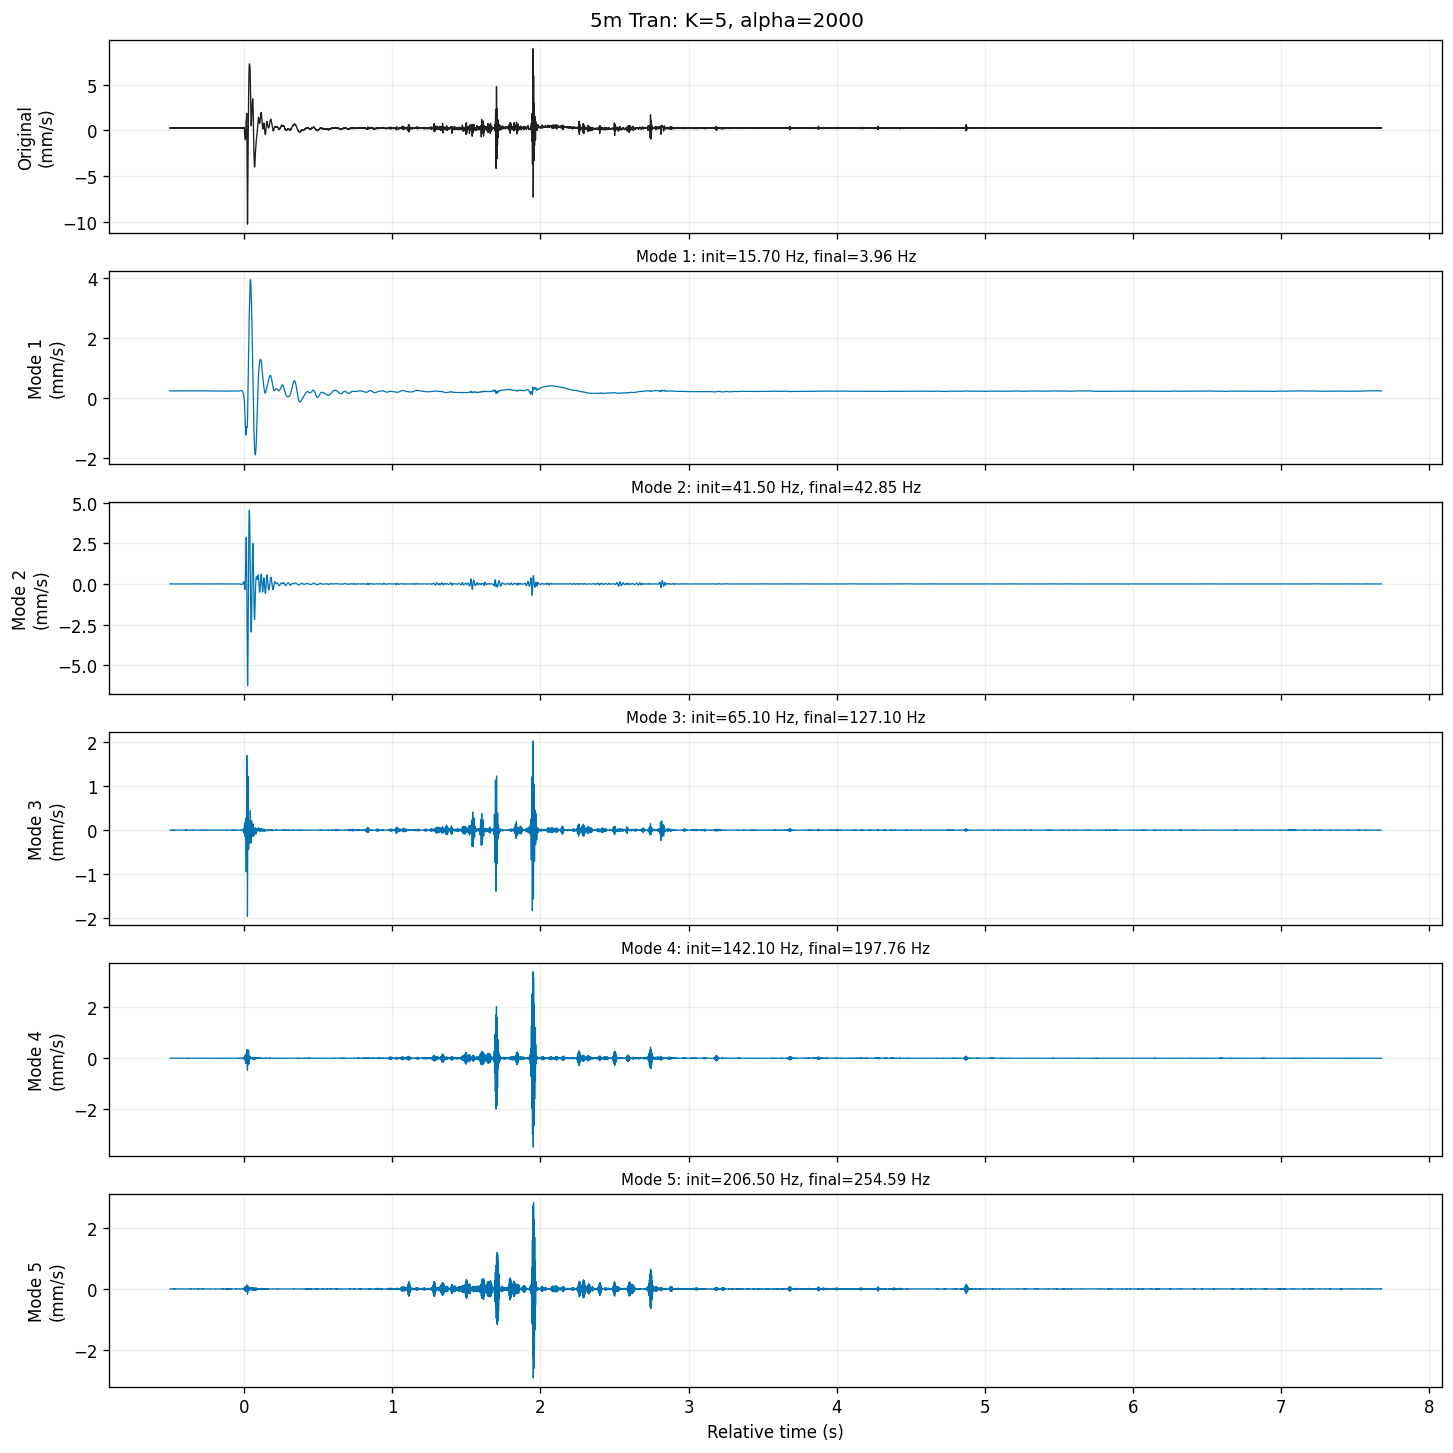

5m/Vert: samples=33493, fs=4096 Hz
  initial centers (Hz): [ 23.9  34.1  71.2 154.6 168.3 220.  237.3]
  final centers (Hz):   [ 13.737  23.855  34.738  44.649  75.462 111.674 224.276]
  iterations=2512, converged=True
  reconstruction RMSE=0.0266073


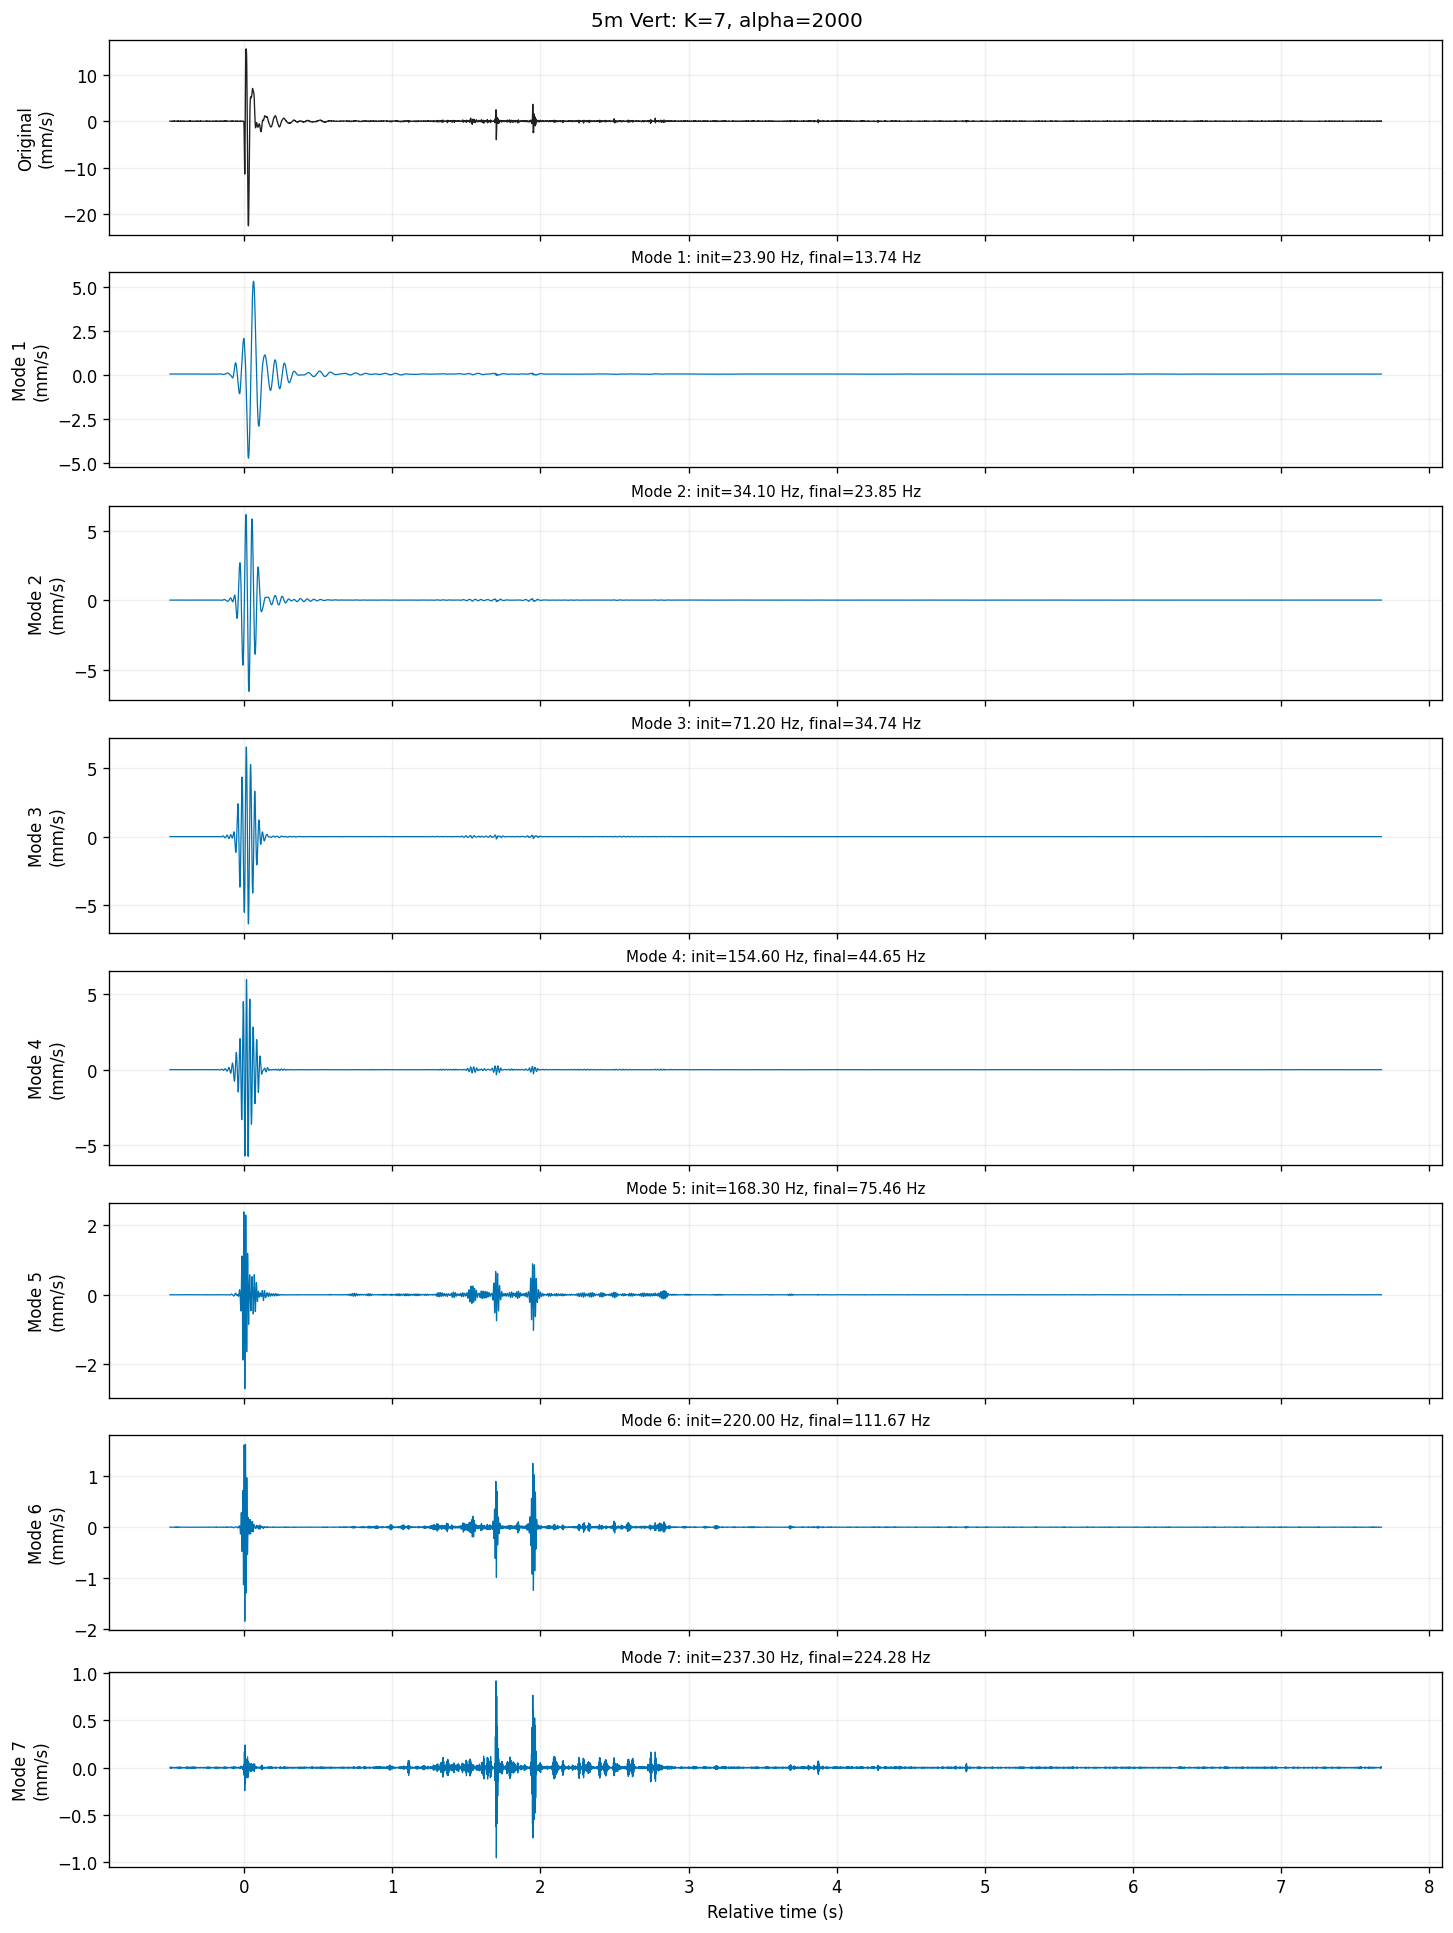

5m/Long: samples=33493, fs=4096 Hz
  initial centers (Hz): [ 15.1  36.2  61.5 111.5 139.3 146.2 208.8 244.6]
  final centers (Hz):   [ 14.578  34.896  61.303 101.563 136.583 166.847 218.017 266.827]
  iterations=641, converged=True
  reconstruction RMSE=0.0264196


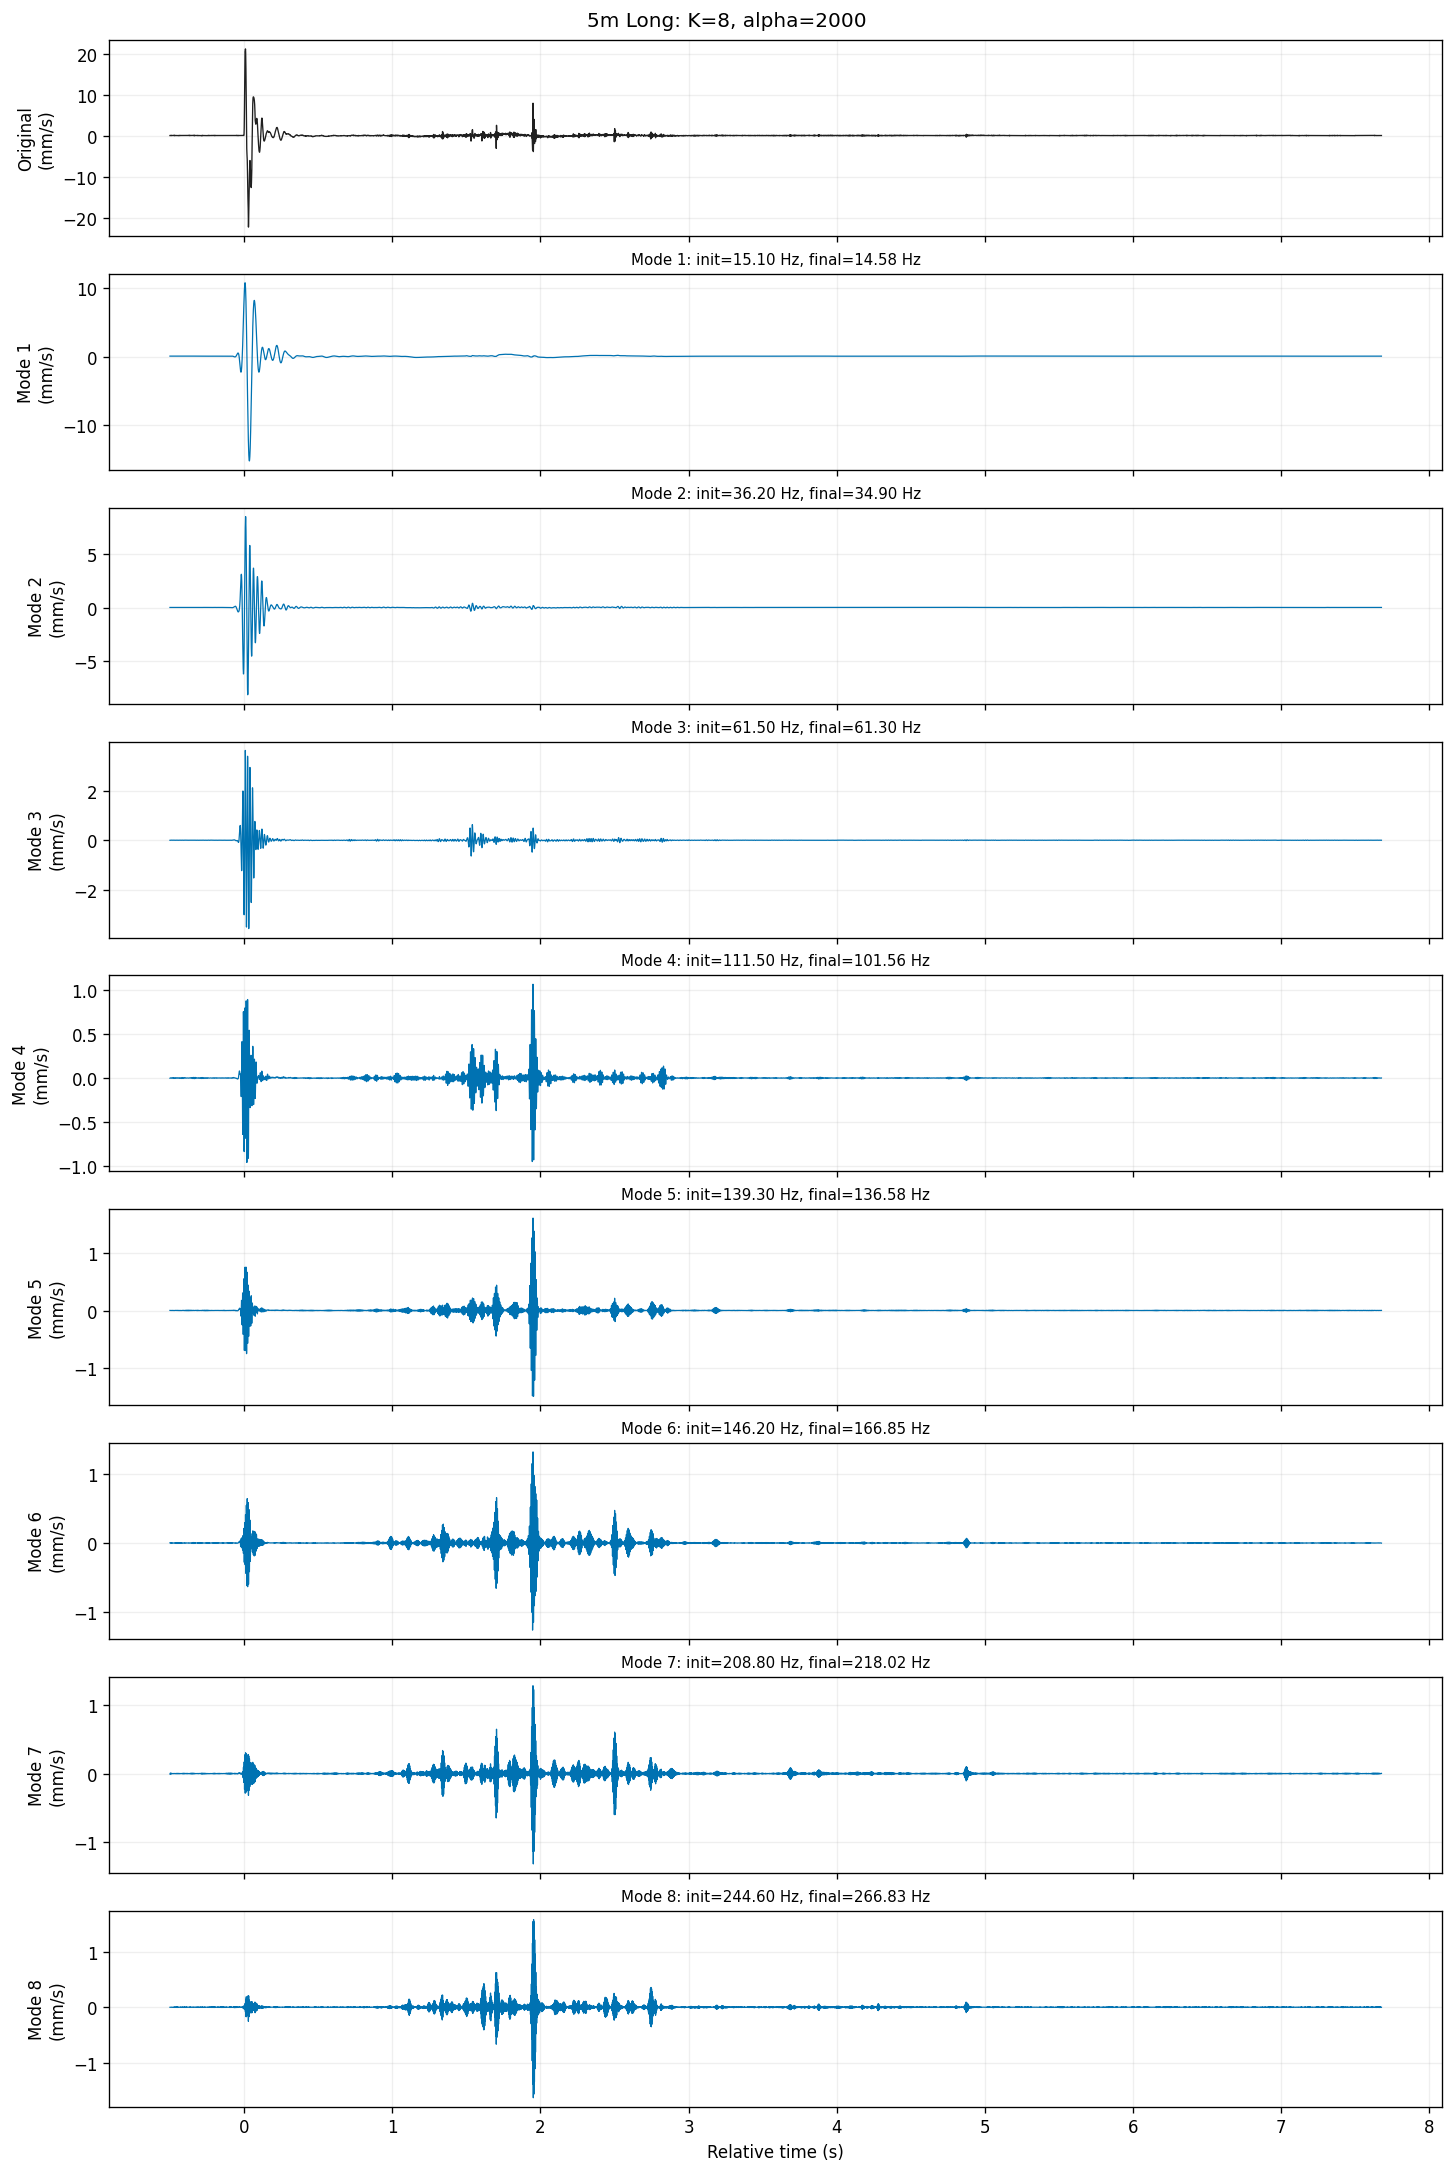

10m/Tran: samples=14336, fs=4096 Hz
  initial centers (Hz): [ 24.   58.4 143.1 205.4 220.3 243.4]
  final centers (Hz):   [ 13.928  24.426  37.107  61.206 143.136 253.667]
  iterations=1864, converged=True
  reconstruction RMSE=0.00953829


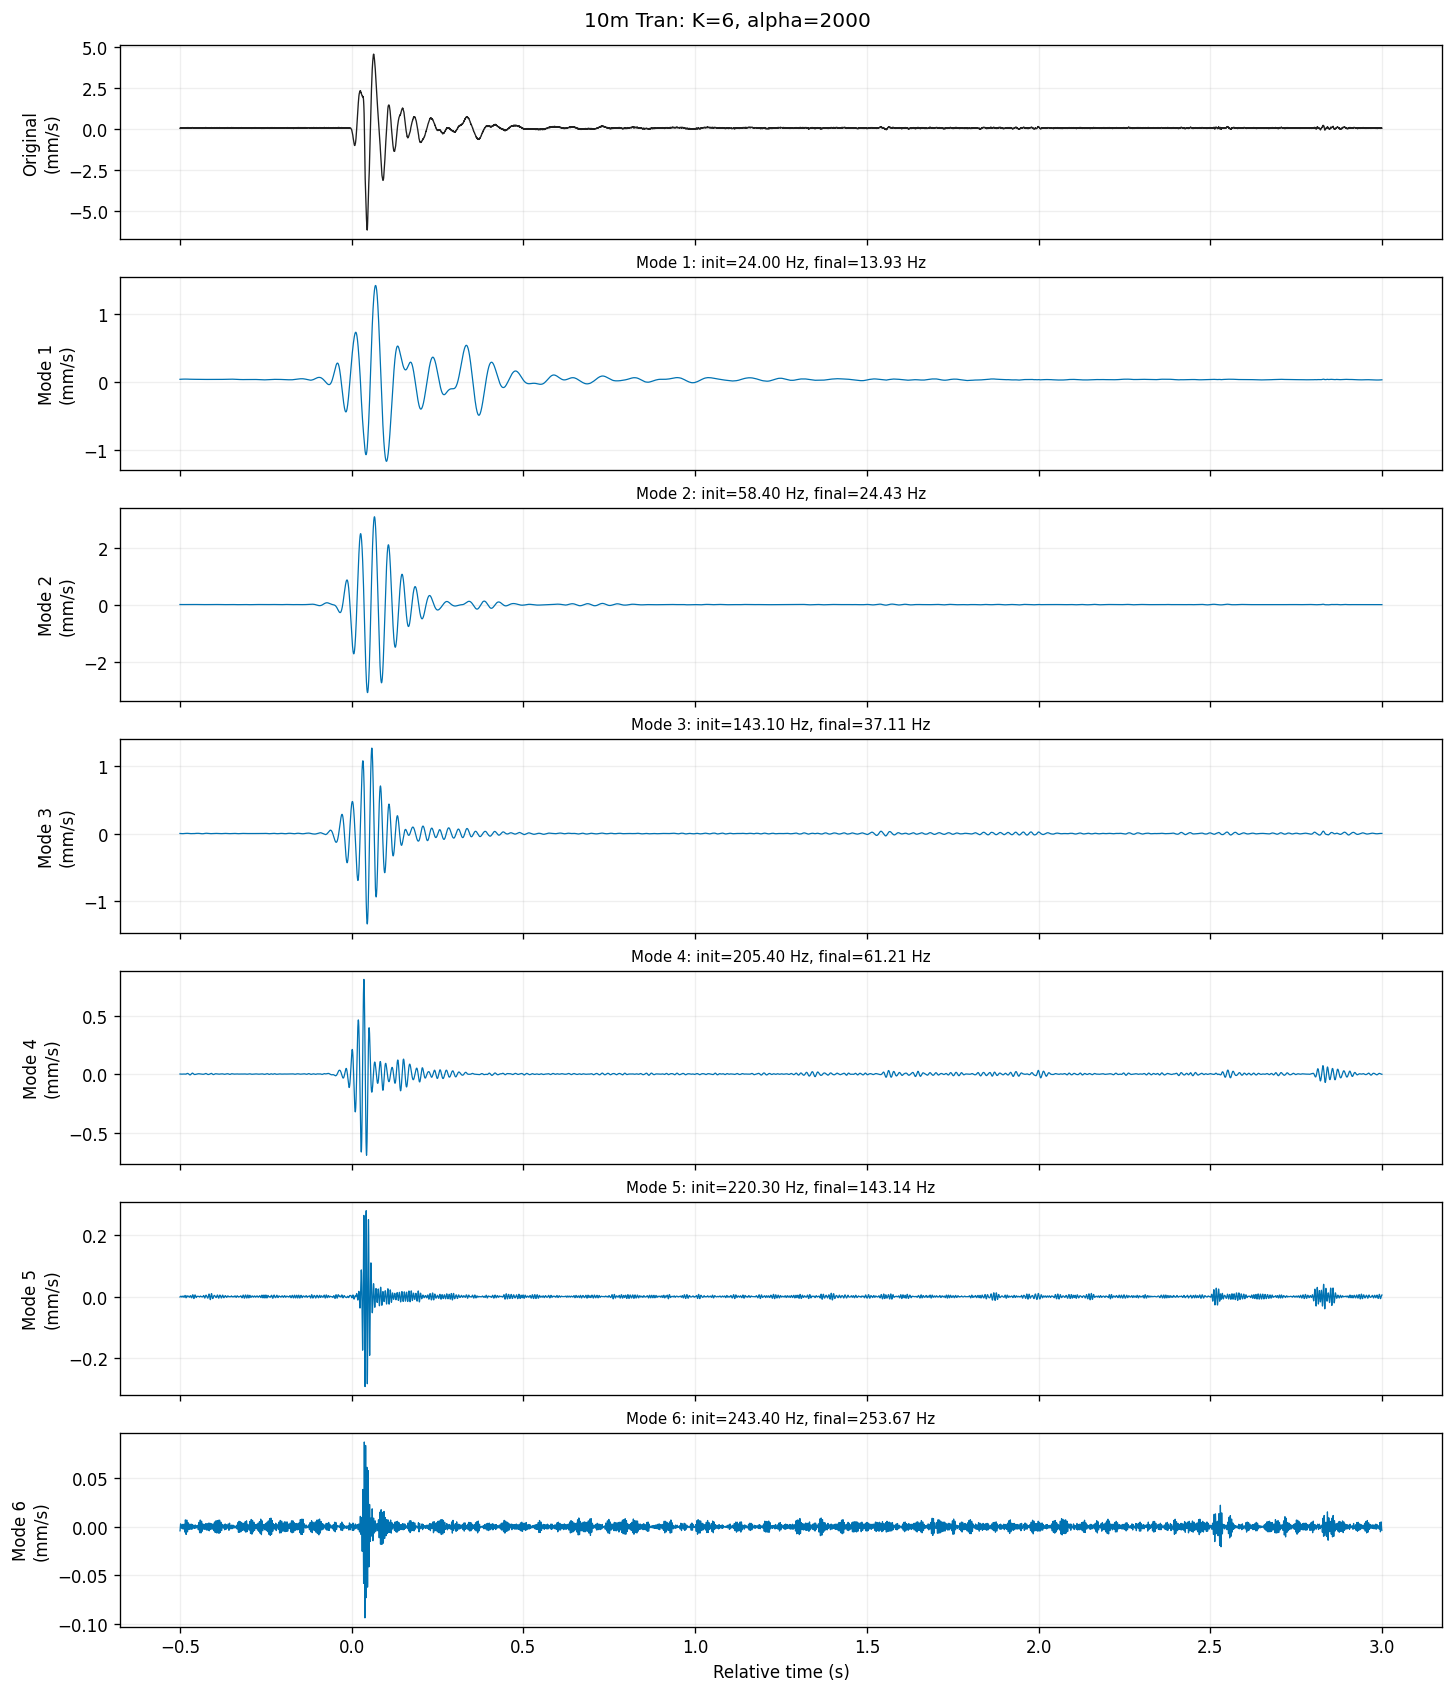

10m/Vert: samples=14336, fs=4096 Hz
  initial centers (Hz): [ 18.3 125.6  36.8  93.  156.9 169.3 188.9 205.2 228.3 243.3]
  final centers (Hz):   [ 13.376  18.286  22.33   27.22   35.204  40.36   46.394  55.374  91.792
 140.767]
  iterations=9999, converged=False
  reconstruction RMSE=0.00879679


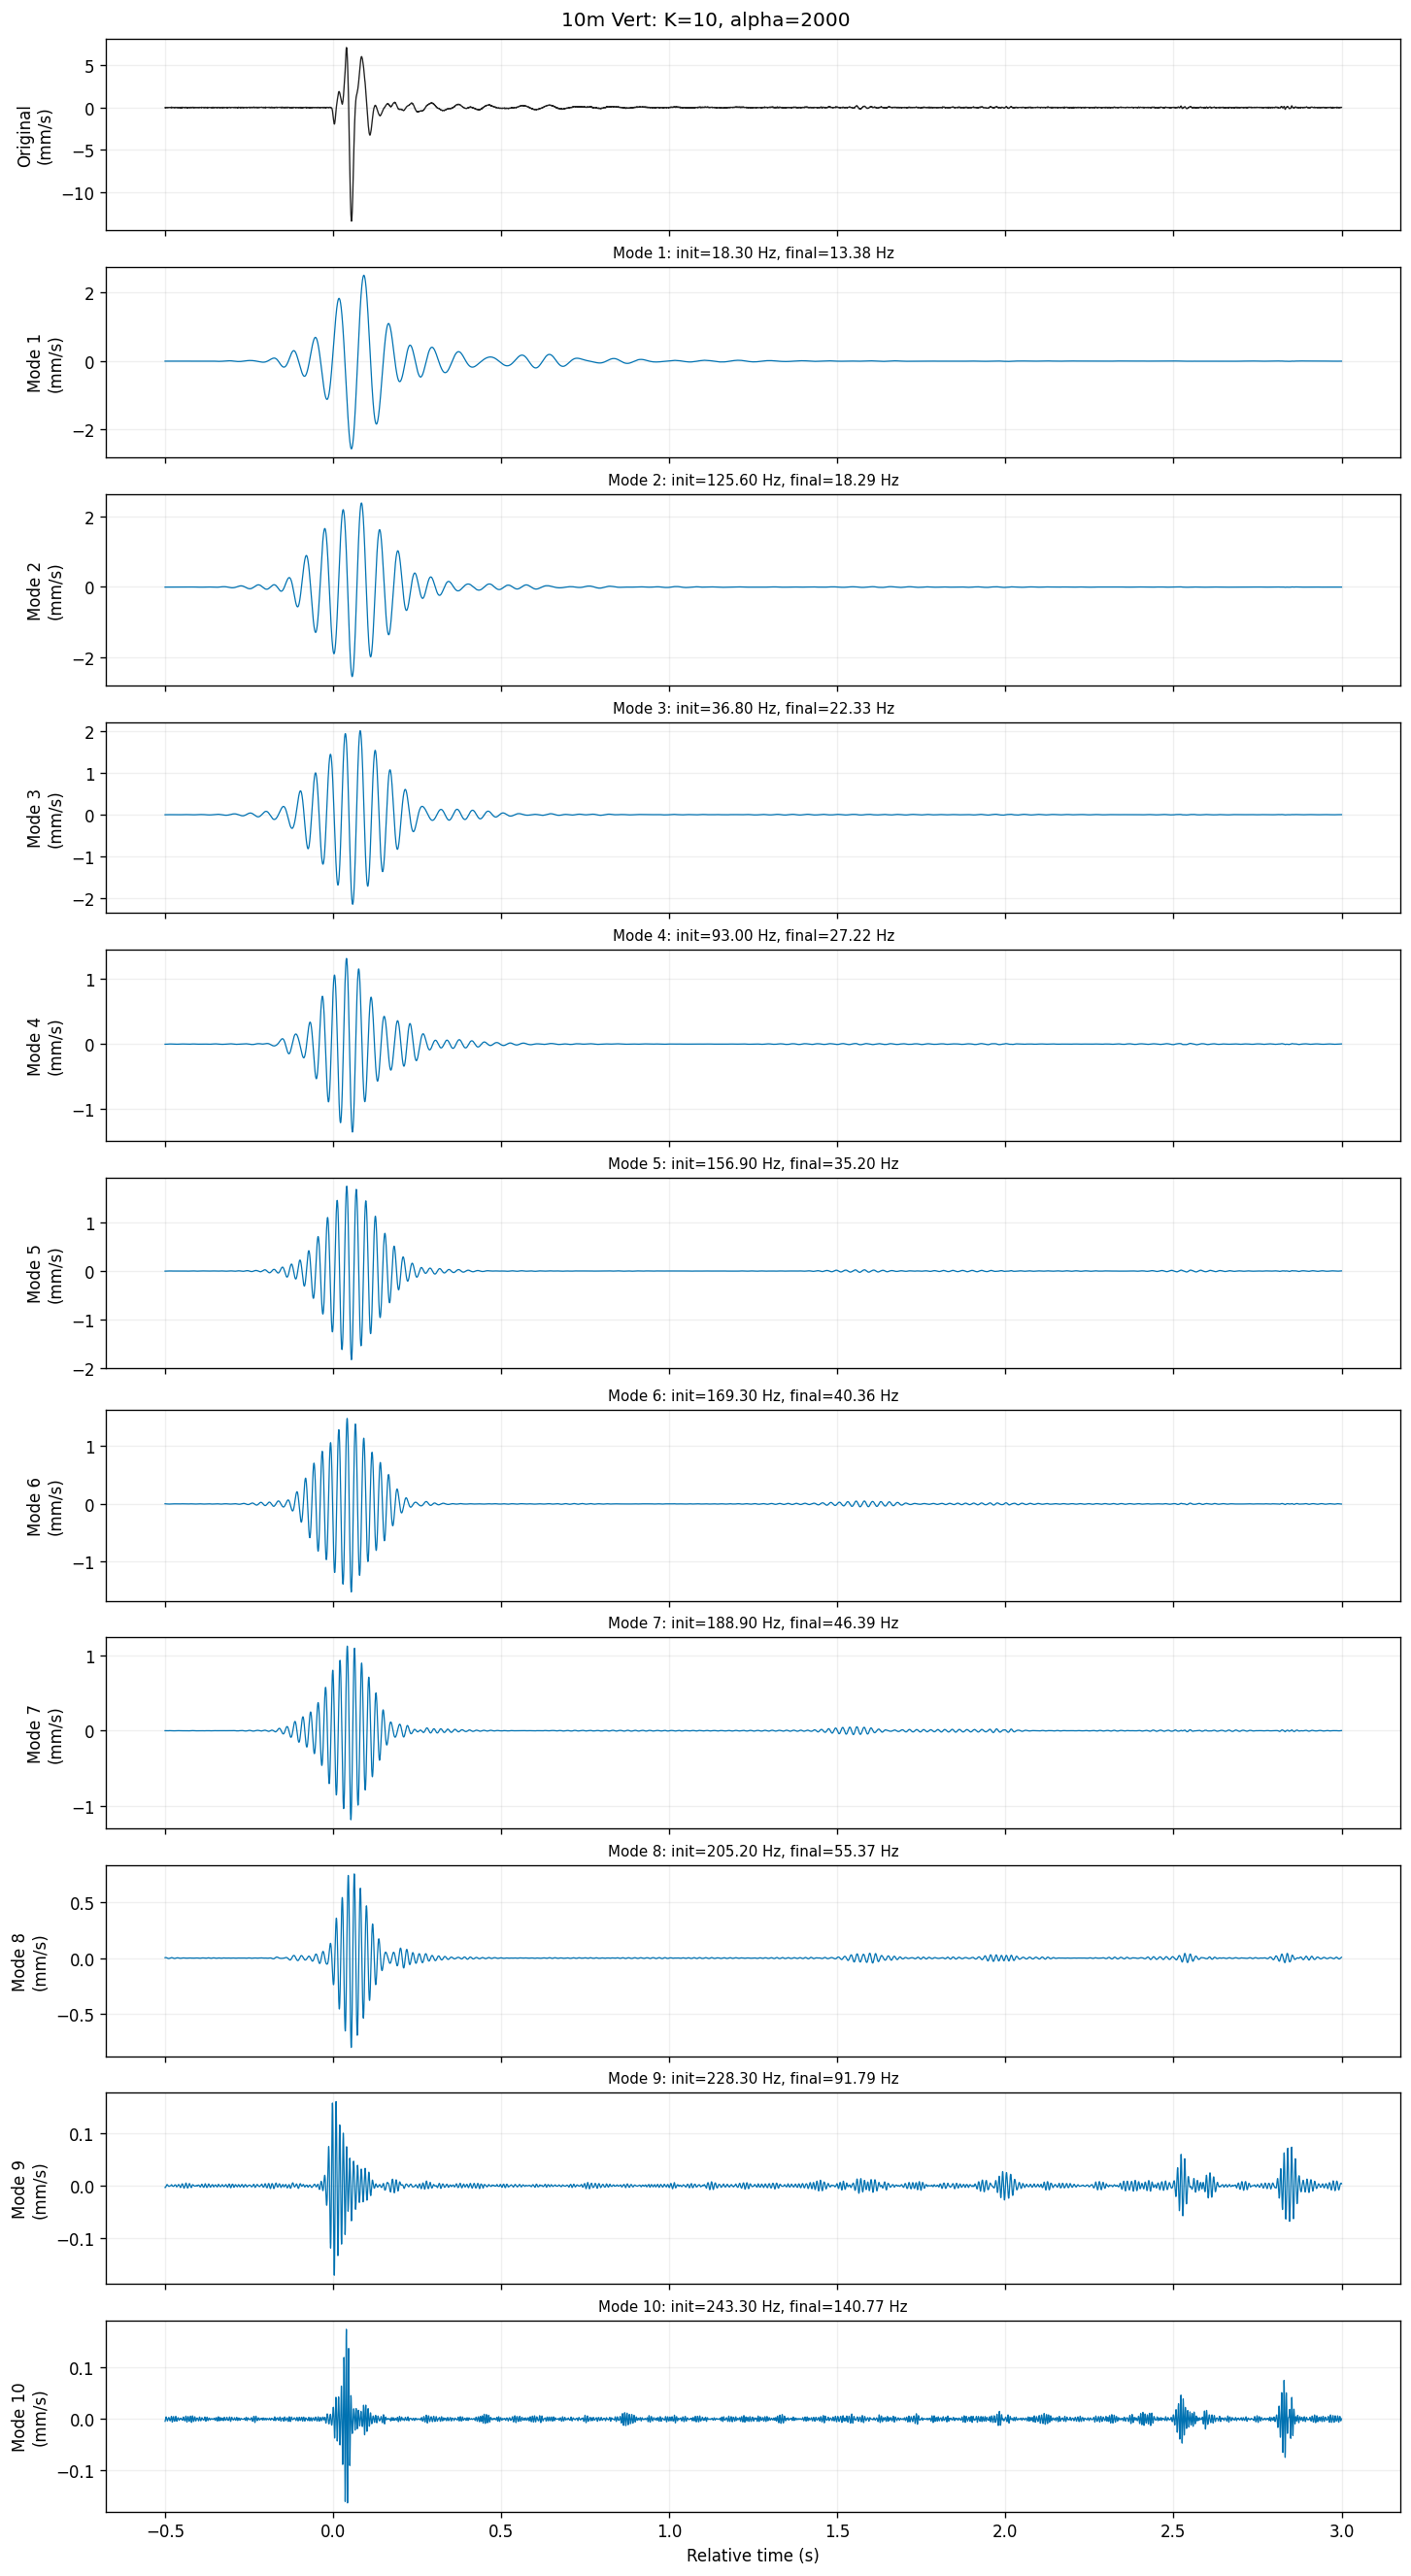

10m/Long: samples=14336, fs=4096 Hz
  initial centers (Hz): [150.5  23.6  63.7 120.7 140.7 191.2 209.3 229.6 245. ]
  final centers (Hz):   [ 13.998  20.796  25.691  35.352  46.272  61.263  72.727 126.517 264.756]
  iterations=9154, converged=True
  reconstruction RMSE=0.00898998


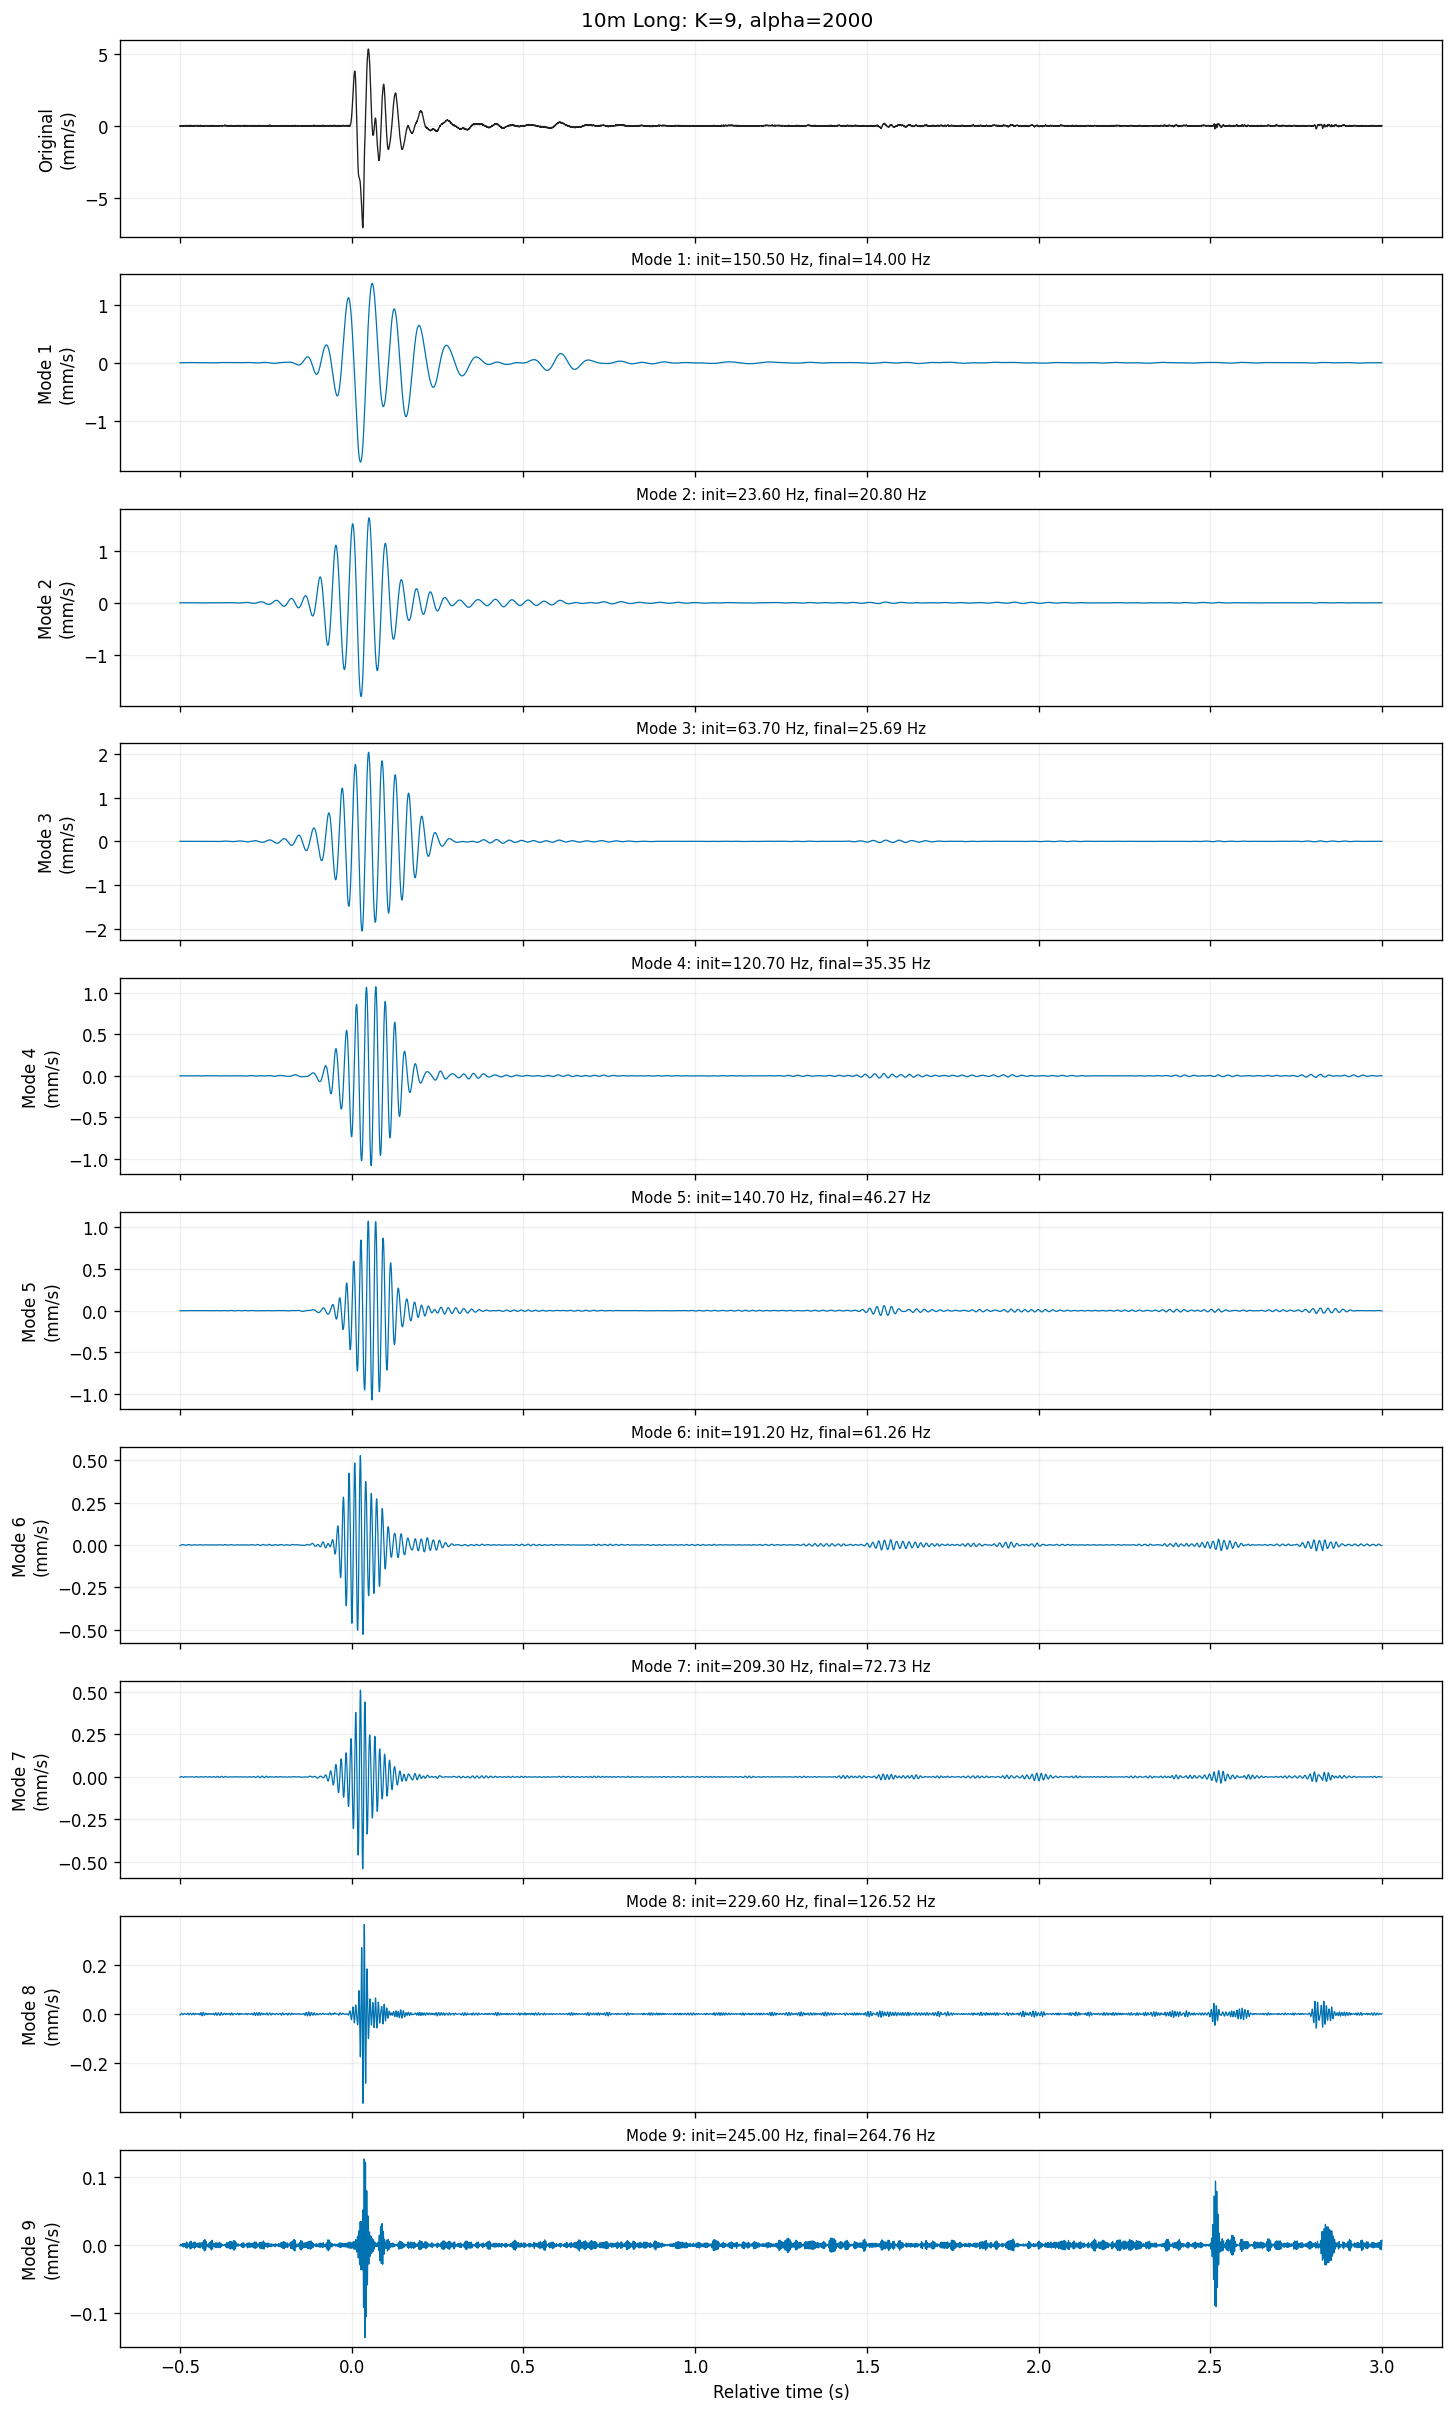

15m/Tran: samples=23176, fs=4096 Hz
  initial centers (Hz): [ 22.2  55.6  82.1 115.6 143.7 178.6 242.5]
  final centers (Hz):   [ 18.129  24.67   51.756  78.347 142.913 244.132 294.781]
  iterations=3123, converged=True
  reconstruction RMSE=0.00997396


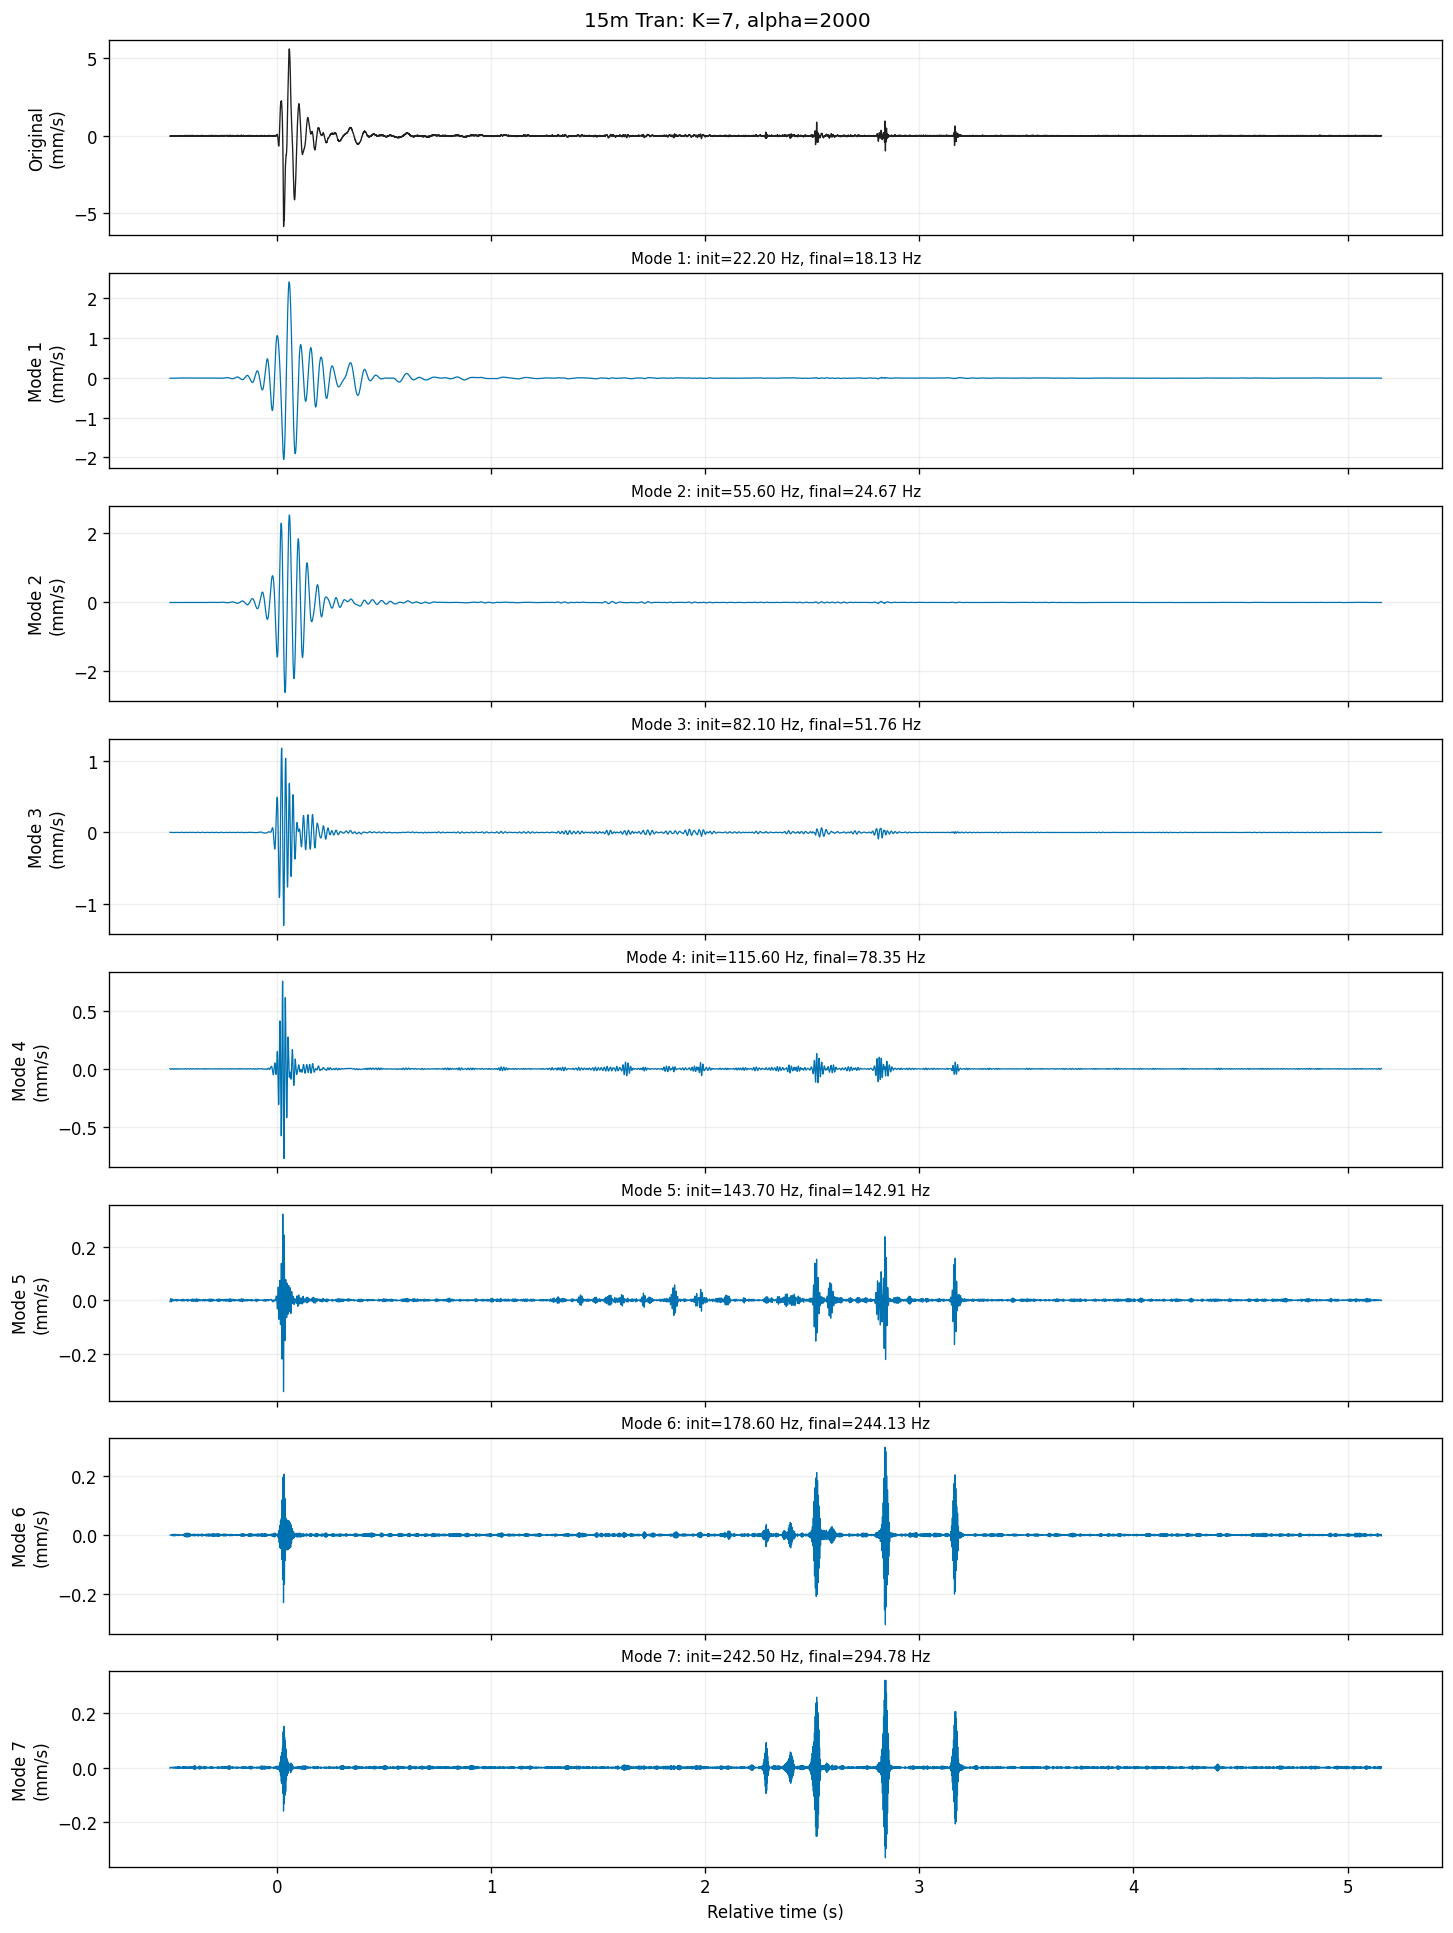

15m/Vert: samples=23176, fs=4096 Hz
  initial centers (Hz): [ 18.9  48.7  84.5 134.4 179.7 200.2 215.2]
  final centers (Hz):   [ 13.701  22.497  47.976  80.654 131.402 183.646 243.944]
  iterations=1559, converged=True
  reconstruction RMSE=0.0117139


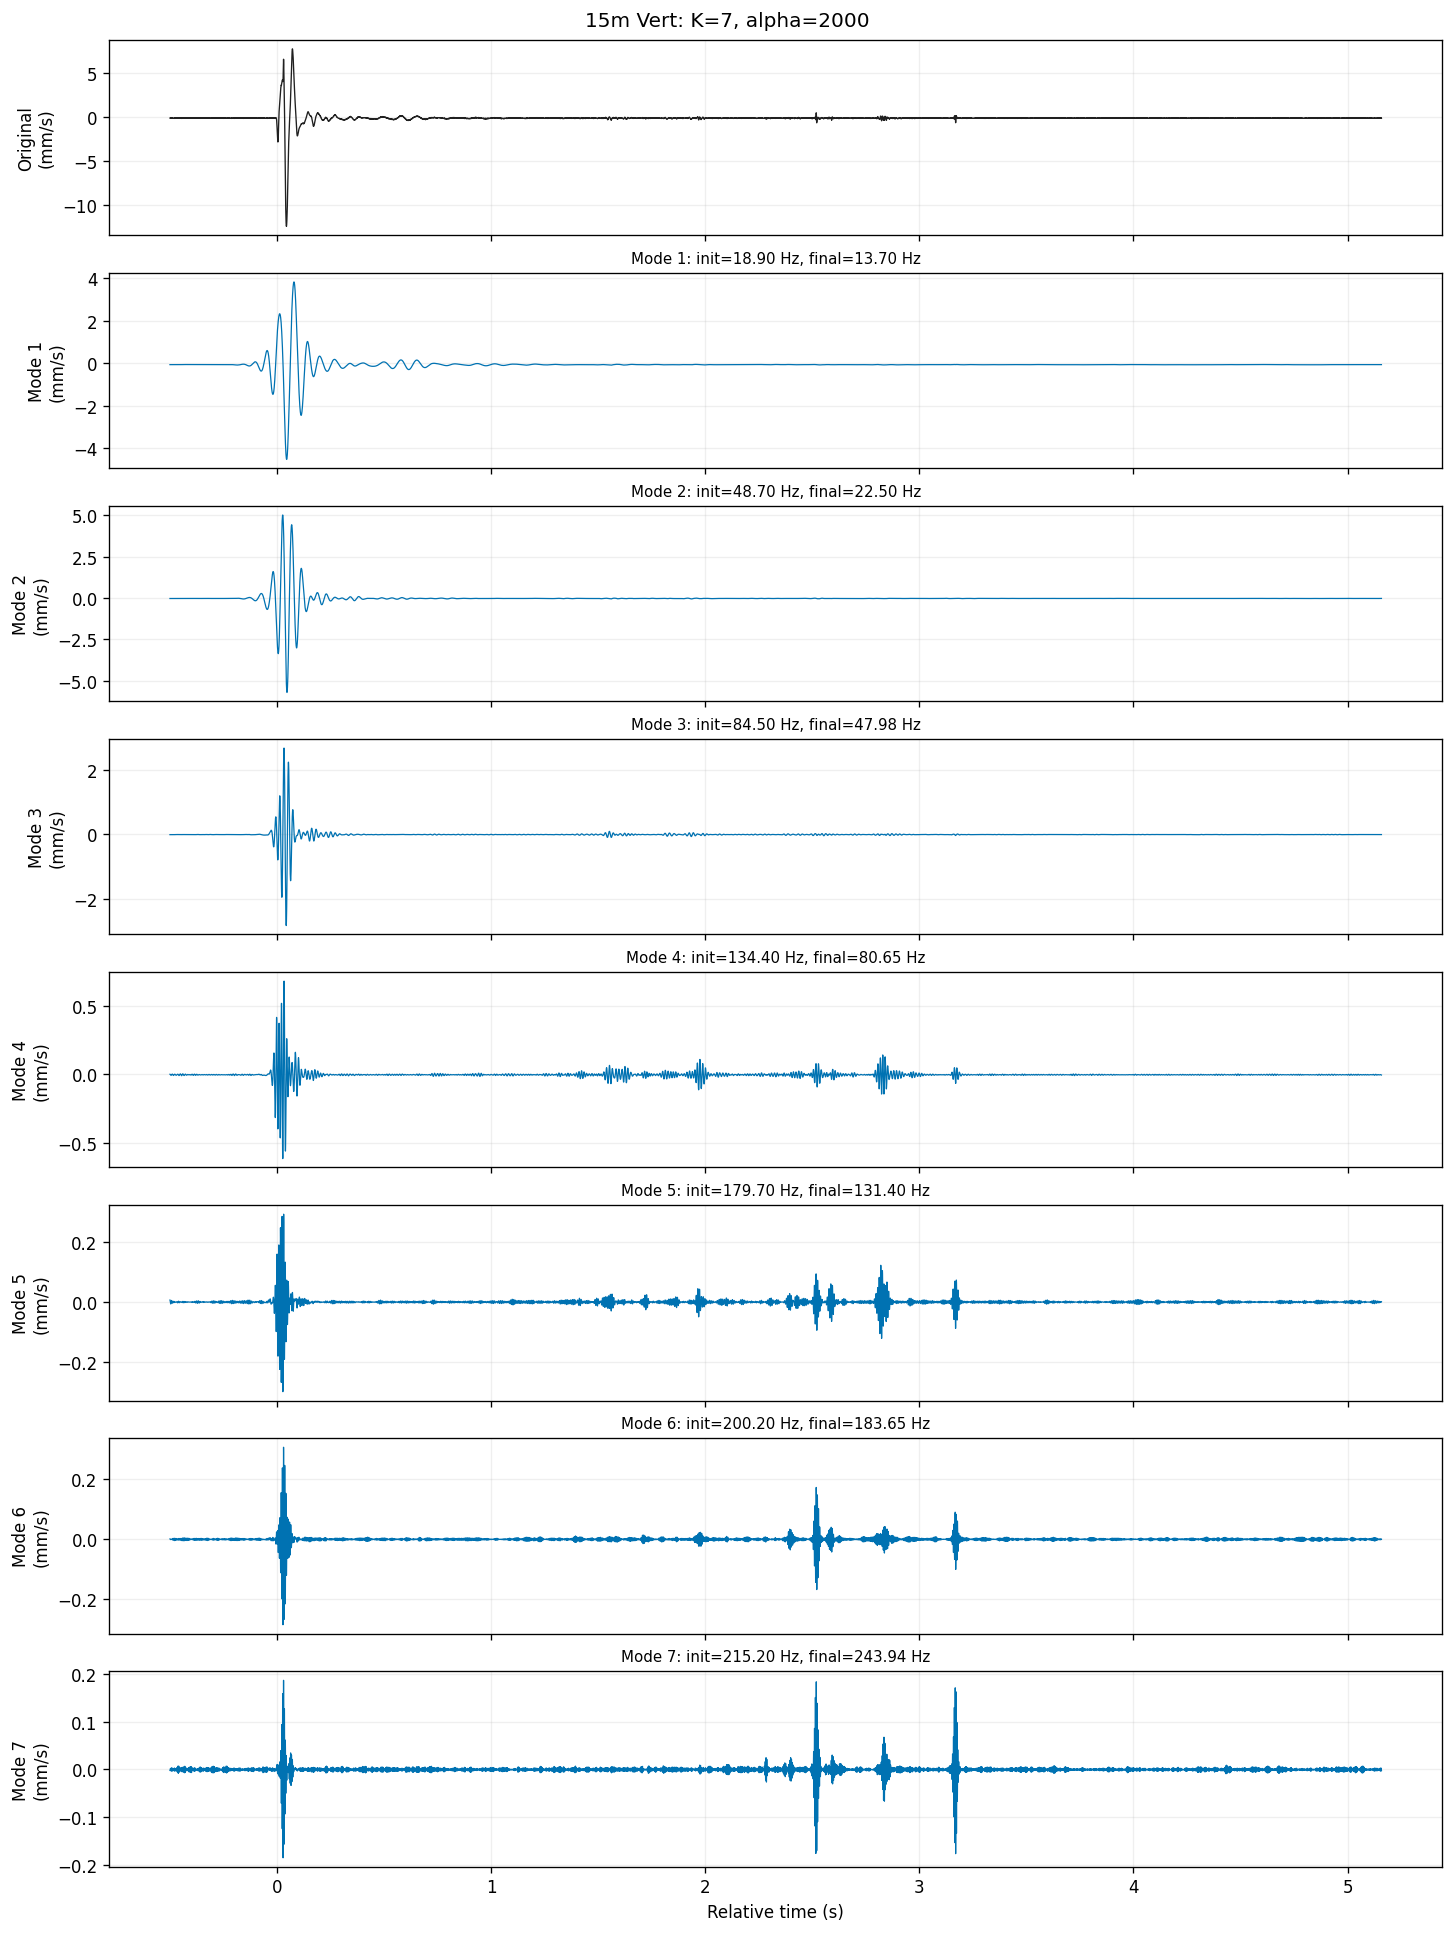

15m/Long: samples=23176, fs=4096 Hz
  initial centers (Hz): [ 35.3  88.2 141.1 203.3 227.1]
  final centers (Hz):   [ 22.015  33.722  40.84   84.978 282.195]
  iterations=2667, converged=True
  reconstruction RMSE=0.0200183


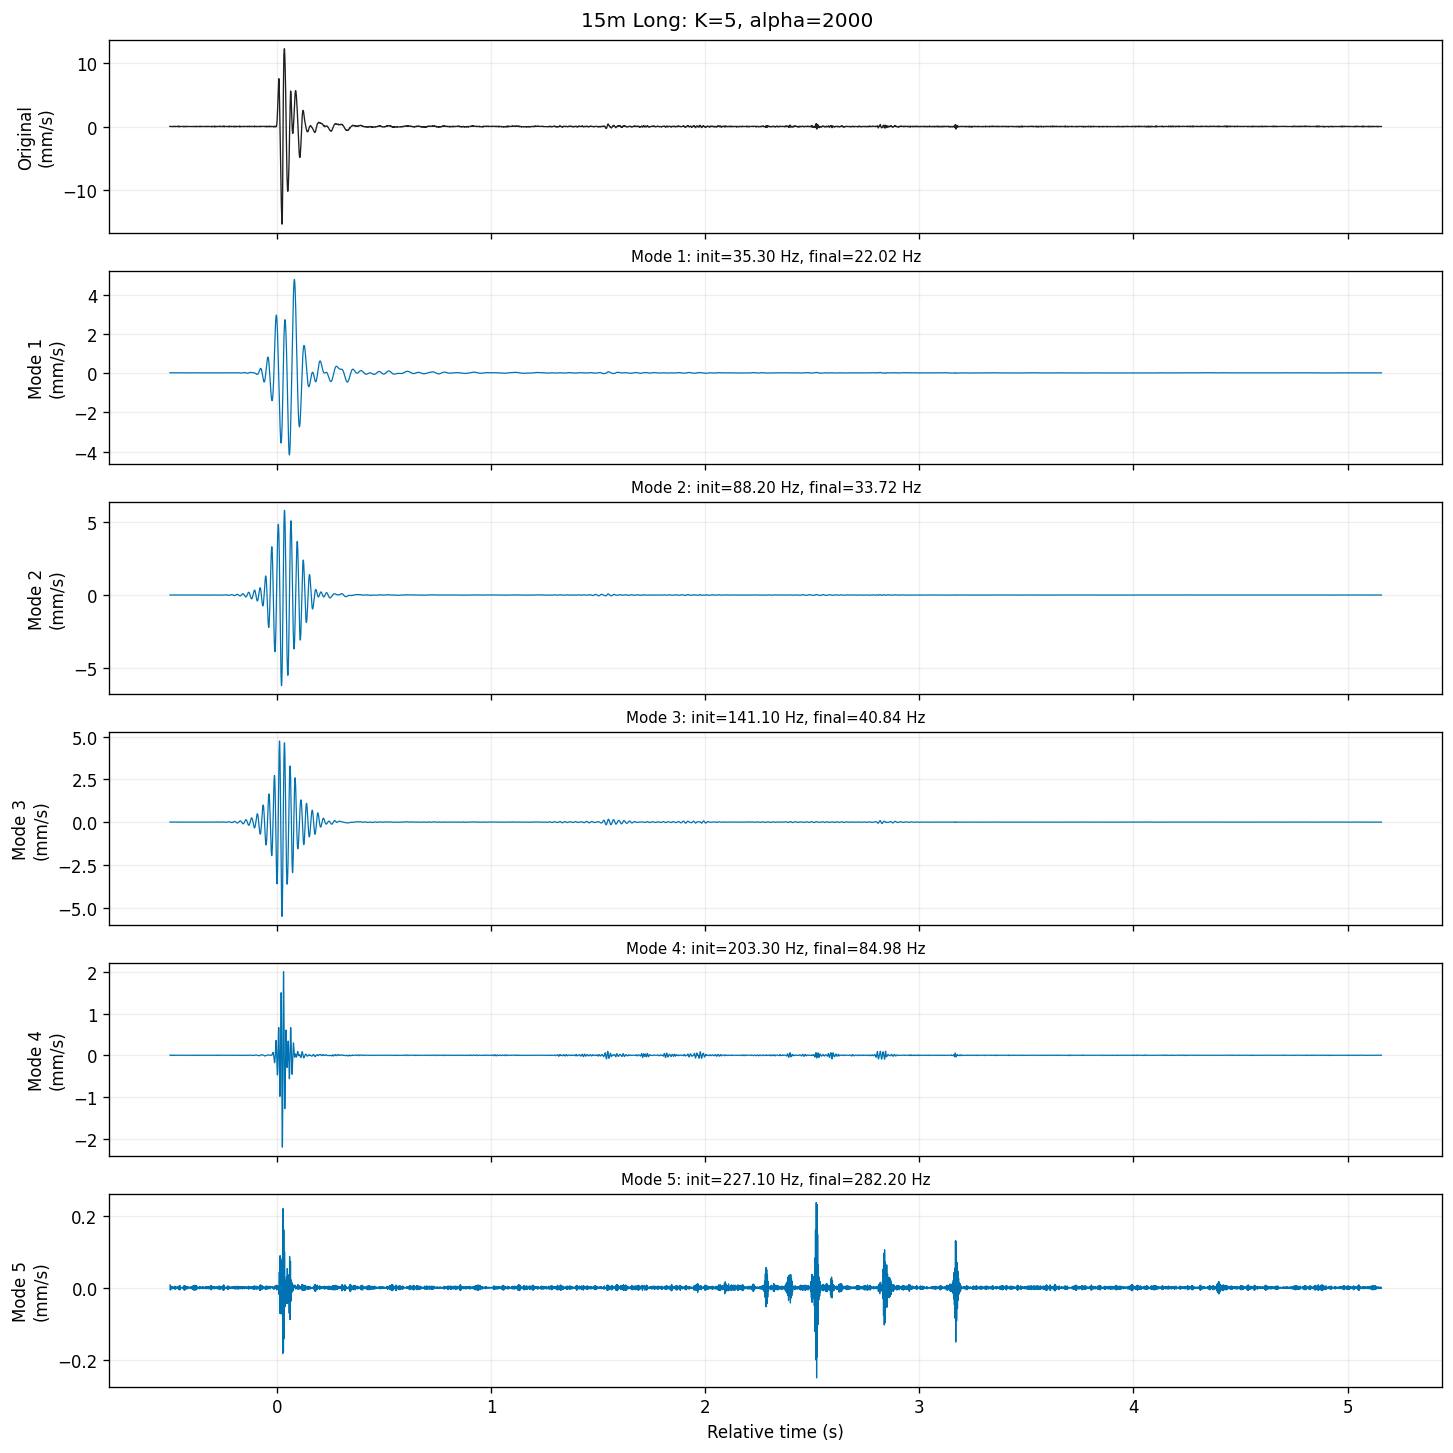

In [12]:
results = analyze_all_records(
    records, VMD_CONFIG, ALPHA, N_FFT, TAU, TOL, MAX_ITERS
)
figures = {}
for distance in ("5m", "10m", "15m"):
    for direction in ("Tran", "Vert", "Long"):
        key = (distance, direction)
        print_vmd_summary(
            distance, direction, records[distance], results[key]
        )
        figures[key] = plot_vmd_modes(
            distance,
            direction,
            records[distance].time_s,
            records[distance].channels[direction],
            results[key],
            unit=records[distance].unit,
            alpha=ALPHA,
        )
        display(figures[key])
        plt.close(figures[key])

In [13]:
# ============================================================
# 将九条信号的原始数据、VMD模态和重构结果保存到一个Excel文件
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd


# 1. 检查VMD分析结果是否已经存在
required_variables = ["records", "results", "ALPHA"]
missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "请先从头运行VMD分析单元格，当前缺少变量："
        + ", ".join(missing_variables)
    )


# 2. 设置Excel保存位置
OUTPUT_EXCEL = Path(
    r"D:\BaiduNetdiskDownload\vmd"
    r"\Short-Time-Variational-Mode-Decomposition"
    r"\vmd_all_modes.xlsx"
)

OUTPUT_EXCEL.parent.mkdir(
    parents=True,
    exist_ok=True,
)


# 3. 用于保存所有模态的参数汇总
summary_rows = []


# 4. 创建Excel工作簿
with pd.ExcelWriter(
    OUTPUT_EXCEL,
    engine="openpyxl",
) as writer:

    # 依次处理九条信号
    for distance in ("5m", "10m", "15m"):
        for direction in ("Tran", "Vert", "Long"):

            key = (distance, direction)

            # 检查当前结果是否存在
            if distance not in records:
                raise KeyError(
                    f"records中缺少距离：{distance}"
                )

            if key not in results:
                raise KeyError(
                    f"results中缺少分析结果：{distance}/{direction}"
                )

            record = records[distance]
            result = results[key]

            time_s = np.asarray(
                record.time_s,
                dtype=float,
            )

            original = np.asarray(
                record.channels[direction],
                dtype=float,
            )

            modes = np.asarray(
                result["modes"],
                dtype=float,
            )

            reconstruction = np.asarray(
                result["reconstruction"],
                dtype=float,
            )

            initial_centers = np.asarray(
                result["initial_centers_hz"],
                dtype=float,
            )

            final_centers = np.asarray(
                result["final_centers_hz"],
                dtype=float,
            )


            # 5. 检查数据长度
            if modes.ndim != 2:
                raise ValueError(
                    f"{distance}/{direction}："
                    "modes必须是二维数组"
                )

            if modes.shape[1] != time_s.size:
                raise ValueError(
                    f"{distance}/{direction}："
                    "模态长度与时间轴长度不一致"
                )

            if original.size != time_s.size:
                raise ValueError(
                    f"{distance}/{direction}："
                    "原始信号长度与时间轴长度不一致"
                )

            if reconstruction.size != time_s.size:
                raise ValueError(
                    f"{distance}/{direction}："
                    "重构信号长度与时间轴长度不一致"
                )


            # 6. 建立当前信号的数据表
            table = {
                "time_s": time_s,
                "original": original,
            }

            # 每个VMD模态占一列
            for mode_index in range(modes.shape[0]):
                column_name = f"mode_{mode_index + 1}"
                table[column_name] = modes[mode_index]

            # 最后一列保存重构信号
            table["reconstruction"] = reconstruction

            dataframe = pd.DataFrame(table)


            # 7. 保存当前信号到独立工作表
            sheet_name = f"{distance}_{direction}"

            dataframe.to_excel(
                writer,
                sheet_name=sheet_name,
                index=False,
            )


            # 8. 保存每个模态的参数摘要
            for mode_index in range(modes.shape[0]):
                mode = modes[mode_index]

                mode_energy = float(
                    np.sum(mode**2)
                )

                mode_rms = float(
                    np.sqrt(np.mean(mode**2))
                )

                summary_rows.append({
                    "distance": distance,
                    "direction": direction,
                    "mode": mode_index + 1,
                    "K": modes.shape[0],
                    "alpha": float(ALPHA),
                    "initial_center_hz":
                        initial_centers[mode_index],
                    "final_center_hz":
                        final_centers[mode_index],
                    "mode_energy": mode_energy,
                    "mode_rms": mode_rms,
                    "reconstruction_rmse":
                        float(result["reconstruction_rmse"]),
                    "iterations":
                        result["iterations"],
                    "converged":
                        result["converged"],
                    "fs_hz":
                        float(record.fs),
                    "unit":
                        record.unit,
                })


    # 9. 将参数摘要保存到summary工作表
    summary_dataframe = pd.DataFrame(
        summary_rows
    )

    summary_dataframe.to_excel(
        writer,
        sheet_name="summary",
        index=False,
    )


# 10. 输出保存结果
print("Excel文件保存成功：")
print(OUTPUT_EXCEL.resolve())
print()
print("共保存信号数量：", 9)
print("汇总模态数量：", len(summary_rows))

Excel文件保存成功：
D:\BaiduNetdiskDownload\vmd\Short-Time-Variational-Mode-Decomposition\vmd_all_modes.xlsx

共保存信号数量： 9
汇总模态数量： 64
